In [28]:
import numpy as np
import json

X_train = np.load('../data/X_train.npy', allow_pickle=True)
X_val   = np.load('../data/X_val.npy', allow_pickle=True)
X_test  = np.load('../data/X_test.npy', allow_pickle=True)
y_train = np.load('../data/y_train.npy', allow_pickle=True)
y_val   = np.load('../data/y_val.npy', allow_pickle=True)
y_test  = np.load('../data/y_test.npy', allow_pickle=True)

with open('../data/feature_names.json') as f:
    feature_names = json.load(f)

print(X_train.shape, X_val.shape, X_test.shape)

(4929, 41) (1057, 41) (1057, 41)


In [29]:
X_train = X_train.astype('float32')
X_val   = X_val.astype('float32')
X_test  = X_test.astype('float32')
y_train = y_train.astype('float32')
y_val   = y_val.astype('float32')
y_test  = y_test.astype('float32')

print(X_train.dtype)   # should now show float32

float32


In [30]:
!pip install tensorflow


In [31]:
import tensorflow as tf, keras
from tensorflow.keras import layers

In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,889 (7.38 KB)

 Trainable params: 1,889 (7.38 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7521 - loss: 0.4876 - val_accuracy: 0.8004 - val_loss: 0.4392
Epoch 2/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8032 - loss: 0.4136 - val_accuracy: 0.7994 - val_loss: 0.4254
Epoch 3/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8062 - loss: 0.4032 - val_accuracy: 0.8013 - val_loss: 0.4243
Epoch 4/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8062 - loss: 0.4008 - val_accuracy: 0.7975 - val_loss: 0.4213
Epoch 5/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8067 - loss: 0.3948 - val_accuracy: 0.7985 - val_loss: 0.4195
Epoch 6/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8131 - loss: 0.3922 - val_accuracy: 0.7975 - val_loss: 0.4214
Epoch 7/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8144 - loss: 0.3904 - val_accuracy: 0.7985 - val_loss: 0.4217
Epoch 8/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8148 - loss: 0.3871 - val_accuracy: 0.

EarlyStopping did exactly its job. Training stopped at epoch 10, not 50. Let's read why.

Look at val_loss across the epochs: it hit its lowest point at epoch 5 (0.4195), then crept back up every epoch after — 0.4214, 0.4217, 0.4216, 0.4222, 0.4238. That's 5 consecutive epochs without improvement, which is exactly your patience=5 setting — so EarlyStopping correctly recognized the plateau and stopped, then (because of restore_best_weights=True) rolled the model back to its epoch-5 weights, not its epoch-10 weights.

This is a textbook mild overfitting signature, and it's worth being precise about what you're seeing:

Training loss keeps dropping the whole time (0.4876 → 0.3825) — the model keeps finding ways to fit the training data better
Validation loss drops early (through epoch 5), then reverses and climbs — the model's improvements after epoch 5 are training-set-specific, not generalizable patterns
Training accuracy keeps climbing (75% → 82%), but validation accuracy is flat-to-declining (80% → 79.5%) — the gap between them is the overfitting tell

The good news: this is mild overfitting, caught early, and EarlyStopping handled it automatically — exactly the mechanism it exists for. Without it, you'd have trained the full 50 epochs and ended up with a model that memorized training noise past epoch 5, then evaluated a worse model than what you actually have now.

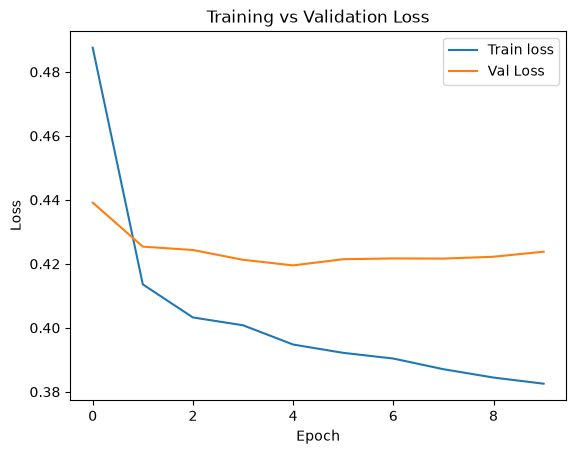

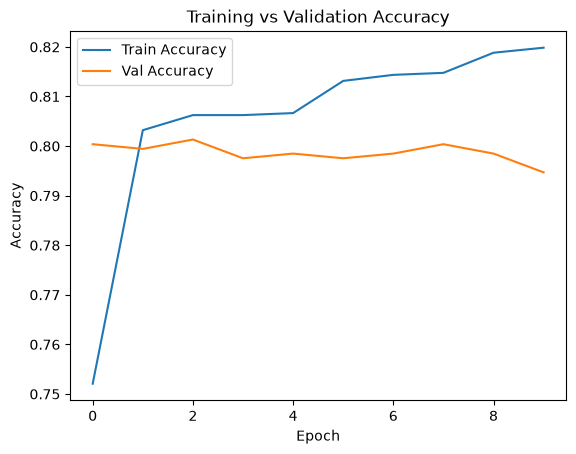

In [37]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label = 'Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

In [38]:
model.save('../models/neural_network.keras')